# Revenue Analysis

**Context:** Behavioral analysis showed that only 32% of users have a purchase event recorded in the tracking system. However, the orders table — the source of truth for actual transactions — shows 86% of users have placed at least one order. This gap reflects a tracking inconsistency in the dataset: not all orders generate a corresponding event. Revenue analysis is based on the orders table. Cart and wishlist actions carry no predictive signal for purchase, and session frequency is the only behavioral differentiator between buyers and non-buyers. This notebook examines the buyer segment: how much they spend, how often they return, and how concentrated that revenue is.

In [10]:
from src.db import run_sql
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [11]:
df     = run_sql("../sql/revenue_mart.sql")
buyers = df[df['total_orders'] > 0].copy()

print(f"Total users:              {len(df):,}")
print(f"Buyers:                   {len(buyers):,}  ({len(buyers)/len(df)*100:.1f}%)")
print(f"Total revenue:            ${buyers['total_spent'].sum():,.0f}")
print(f"Avg revenue per buyer:    ${buyers['total_spent'].mean():,.2f}")
print(f"Median revenue per buyer: ${buyers['total_spent'].median():,.2f}")
print(f"Overall AOV:              ${buyers['avg_order_value'].mean():,.2f}")

Total users:              10,000
Buyers:                   8,635  (86.4%)
Total revenue:            $11,918,669
Avg revenue per buyer:    $1,380.27
Median revenue per buyer: $921.05
Overall AOV:              $593.79


## 1. Revenue Summary (Buyers Only)

In [12]:
buyers[['total_orders', 'total_spent', 'avg_order_value', 'customer_lifetime_days', 'days_since_last_order']].describe().round(2)

,total_orders,total_spent,avg_order_value,customer_lifetime_days,days_since_last_order
count,8635.00,8635.00,8635.00,8635.00,8635.00
mean,2.32,1380.27,593.79,213.46,237.42
std,1.28,1399.58,579.99,204.42,181.36
min,1.00,1.78,1.78,0.00,0.00
25%,1.00,362.08,207.22,0.00,84.00
50%,2.00,921.05,428.86,181.00,194.00
75%,3.00,1944.50,789.98,388.00,362.00
max,10.00,13288.88,7013.55,681.00,683.00


Users typically make only 1–3 purchases over their lifecycle, with a median of 2 orders and a relatively long but inconsistent engagement period, suggesting that repeat purchasing is not deeply established across the entire user base

## 2. AOV Distribution

AOV  —  Median: $428.86  |  Mean: $593.79  |  Gap: $164.93


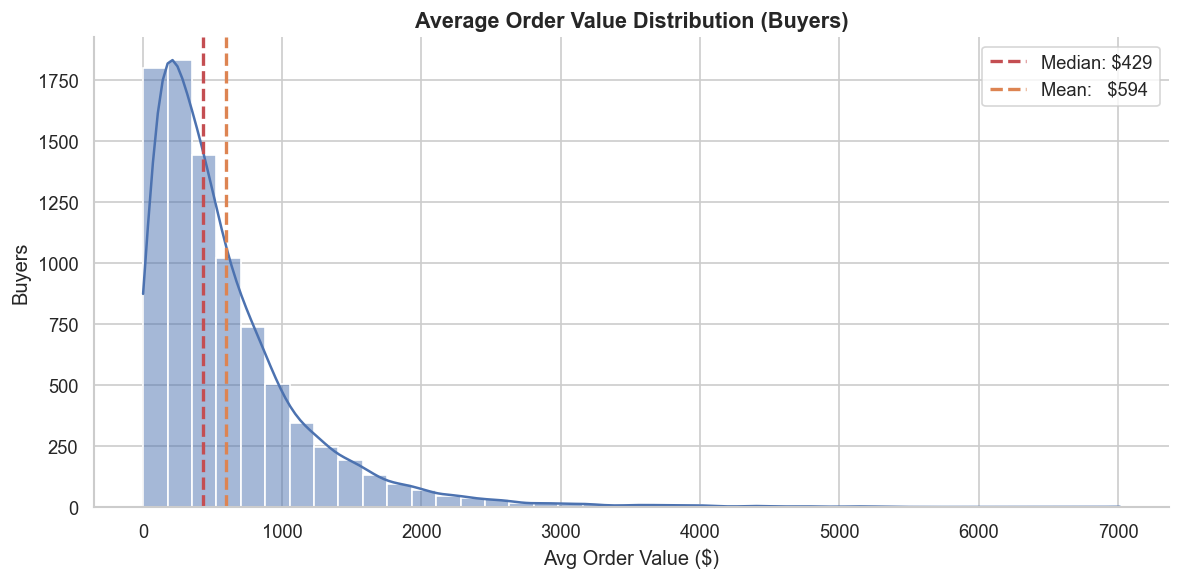

In [13]:
median_aov = buyers['avg_order_value'].median()
mean_aov   = buyers['avg_order_value'].mean()

print(f"AOV  —  Median: ${median_aov:.2f}  |  Mean: ${mean_aov:.2f}  |  Gap: ${mean_aov - median_aov:.2f}")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=buyers, x='avg_order_value', bins=40, kde=True, color='#4C72B0', ax=ax)
ax.axvline(median_aov, color='#C44E52', linestyle='--', linewidth=2, label=f"Median: ${median_aov:.0f}")
ax.axvline(mean_aov,   color='#DD8452', linestyle='--', linewidth=2, label=f"Mean:   ${mean_aov:.0f}")
ax.set_title("Average Order Value Distribution (Buyers)", fontsize=13, fontweight='bold')
ax.set_xlabel("Avg Order Value ($)")
ax.set_ylabel("Buyers")
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

A few large orders are increasing the average order value, meaning most users spend less than the reported average

## 3. One-Time vs Repeat Buyers

In [14]:
buyers['buyer_type']  = buyers['total_orders'].apply(lambda x: 'One-Time' if x == 1 else 'Repeat')
type_counts           = buyers['buyer_type'].value_counts()
type_revenue          = buyers.groupby('buyer_type')['total_spent'].sum()
type_revenue_pct      = (type_revenue / type_revenue.sum() * 100).round(1)
type_avg_spend        = buyers.groupby('buyer_type')['total_spent'].mean()

for t in ['One-Time', 'Repeat']:
    n = type_counts.get(t, 0)
    print(f"{t:<12}  buyers: {n:,} ({n/len(buyers)*100:.1f}%)  "
          f"revenue: ${type_revenue.get(t,0):,.0f} ({type_revenue_pct.get(t,0):.1f}%)  "
          f"avg spend: ${type_avg_spend.get(t,0):.0f}")

One-Time      buyers: 2,741 (31.7%)  revenue: $1,580,530 (13.3%)  avg spend: $577
Repeat        buyers: 5,894 (68.3%)  revenue: $10,338,139 (86.7%)  avg spend: $1754


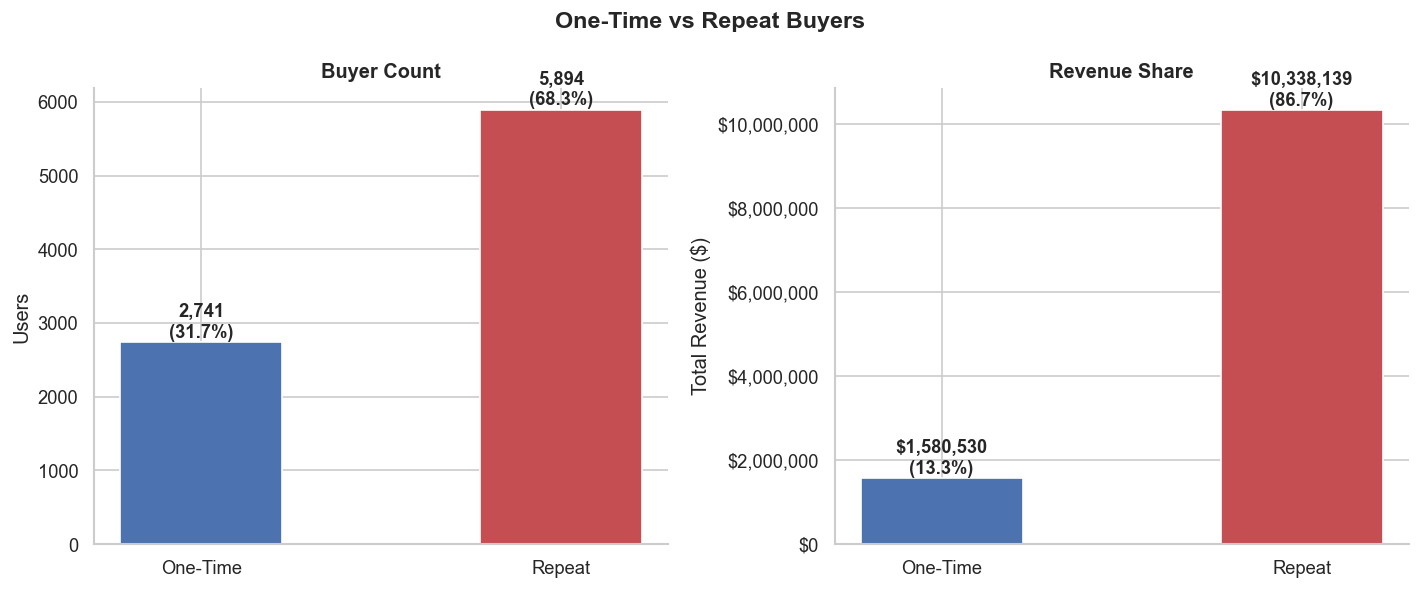

In [15]:
order  = ['One-Time', 'Repeat']
colors = ['#4C72B0', '#C44E52']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

vals_count = [type_counts.get(t, 0) for t in order]
bars = axes[0].bar(order, vals_count, color=colors, width=0.45, edgecolor='white')
for bar, val in zip(bars, vals_count):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f"{val:,}\n({val/len(buyers)*100:.1f}%)",
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title("Buyer Count", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Users")
sns.despine(ax=axes[0])

vals_rev = [type_revenue.get(t, 0) for t in order]
bars2 = axes[1].bar(order, vals_rev, color=colors, width=0.45, edgecolor='white')
for bar, val, pct in zip(bars2, vals_rev, [type_revenue_pct.get(t, 0) for t in order]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"${val:,.0f}\n({pct:.1f}%)",
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title("Revenue Share", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Total Revenue ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
sns.despine(ax=axes[1])

fig.suptitle("One-Time vs Repeat Buyers", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Most revenue comes from repeat customers (86.7%), and they spend significantly more than one-time buyers, so keeping customers is more important than getting new ones.

## 4. Revenue Concentration

Top 10% of buyers → 33.4% of revenue
Top 20% of buyers → 53.0% of revenue


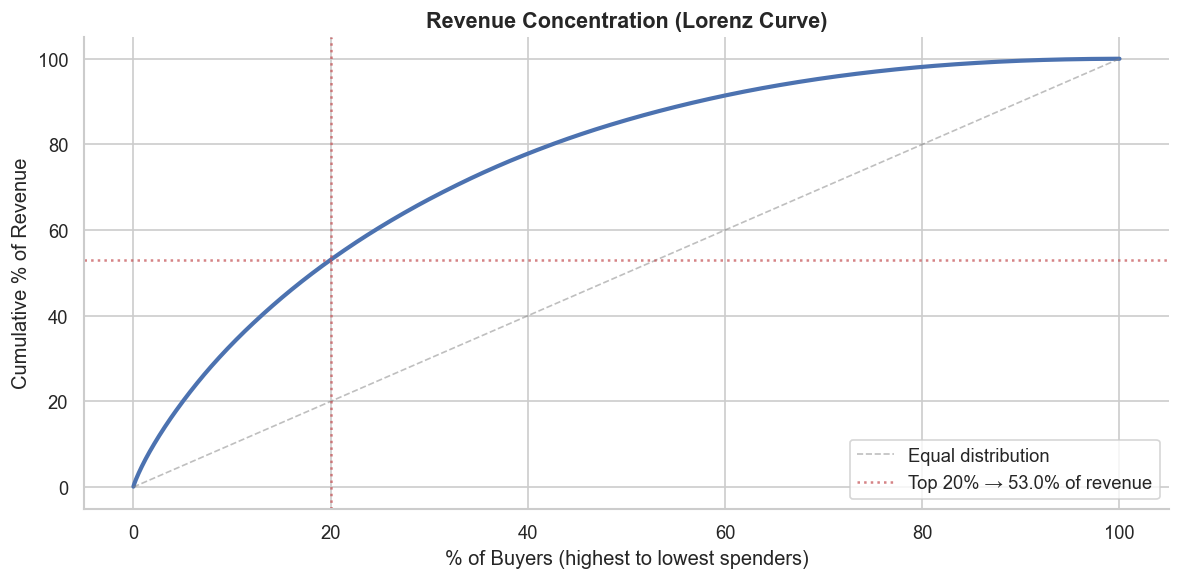

In [16]:
sorted_buyers = buyers.sort_values('total_spent', ascending=False).reset_index(drop=True)
sorted_buyers['pct_users']   = (sorted_buyers.index + 1) / len(sorted_buyers) * 100
sorted_buyers['cum_revenue'] = sorted_buyers['total_spent'].cumsum() / sorted_buyers['total_spent'].sum() * 100

top10_rev = sorted_buyers.loc[sorted_buyers['pct_users'] <= 10, 'cum_revenue'].max()
top20_rev = sorted_buyers.loc[sorted_buyers['pct_users'] <= 20, 'cum_revenue'].max()
print(f"Top 10% of buyers → {top10_rev:.1f}% of revenue")
print(f"Top 20% of buyers → {top20_rev:.1f}% of revenue")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sorted_buyers['pct_users'], sorted_buyers['cum_revenue'], color='#4C72B0', linewidth=2.5)
ax.plot([0, 100], [0, 100], color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Equal distribution')
ax.axvline(20, color='#C44E52', linestyle=':', linewidth=1.5, alpha=0.7)
ax.axhline(top20_rev, color='#C44E52', linestyle=':', linewidth=1.5, alpha=0.7,
           label=f"Top 20% → {top20_rev:.1f}% of revenue")
ax.set_title("Revenue Concentration (Lorenz Curve)", fontsize=13, fontweight='bold')
ax.set_xlabel("% of Buyers (highest to lowest spenders)")
ax.set_ylabel("Cumulative % of Revenue")
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

Most revenue comes from a small group of users (top 20%), who generate over half of all sales

## 5. RFM Segmentation

Using three dimensions from `revenue_mart`: Recency (`days_since_last_order`), Frequency (`total_orders`), Monetary (`total_spent`). Each buyer is scored 1–3 per dimension based on tertiles, then grouped into segments.

In [17]:
# Score Recency
buyers['R'] = pd.qcut(buyers['days_since_last_order'], q=3, labels=[3, 2, 1]).astype(int)

# Score Frequency
buyers['F'] = pd.qcut(buyers['total_orders'].rank(method='first'), q=3, labels=[1, 2, 3]).astype(int)

# Score Monetary
buyers['M'] = pd.qcut(buyers['total_spent'], q=3, labels=[1, 2, 3]).astype(int)

buyers['RFM_score'] = buyers['R'] + buyers['F'] + buyers['M']

def rfm_segment(score):
    if score >= 8:   return 'Champions'
    elif score >= 6: return 'Loyal'
    elif score >= 4: return 'At Risk'
    else:            return 'Lost'

buyers['rfm_segment'] = buyers['RFM_score'].apply(rfm_segment)

seg_order = ['Champions', 'Loyal', 'At Risk', 'Lost']
rfm_summary = buyers.groupby('rfm_segment').agg(
    count       = ('user_id', 'count'),
    avg_spend   = ('total_spent', 'mean'),
    avg_orders  = ('total_orders', 'mean'),
    avg_recency = ('days_since_last_order', 'mean')
).reindex(seg_order).round(1)

rfm_summary['share_%'] = (rfm_summary['count'] / len(buyers) * 100).round(1)
print(rfm_summary[['count', 'share_%', 'avg_spend', 'avg_orders', 'avg_recency']])

             count  share_%  avg_spend  avg_orders  avg_recency
rfm_segment                                                    
Champions     2284     26.5     2664.7         3.8         90.5
Loyal         2755     31.9     1455.5         2.4        196.9
At Risk       2539     29.4      638.3         1.5        308.6
Lost          1057     12.2      191.0         1.0        489.5


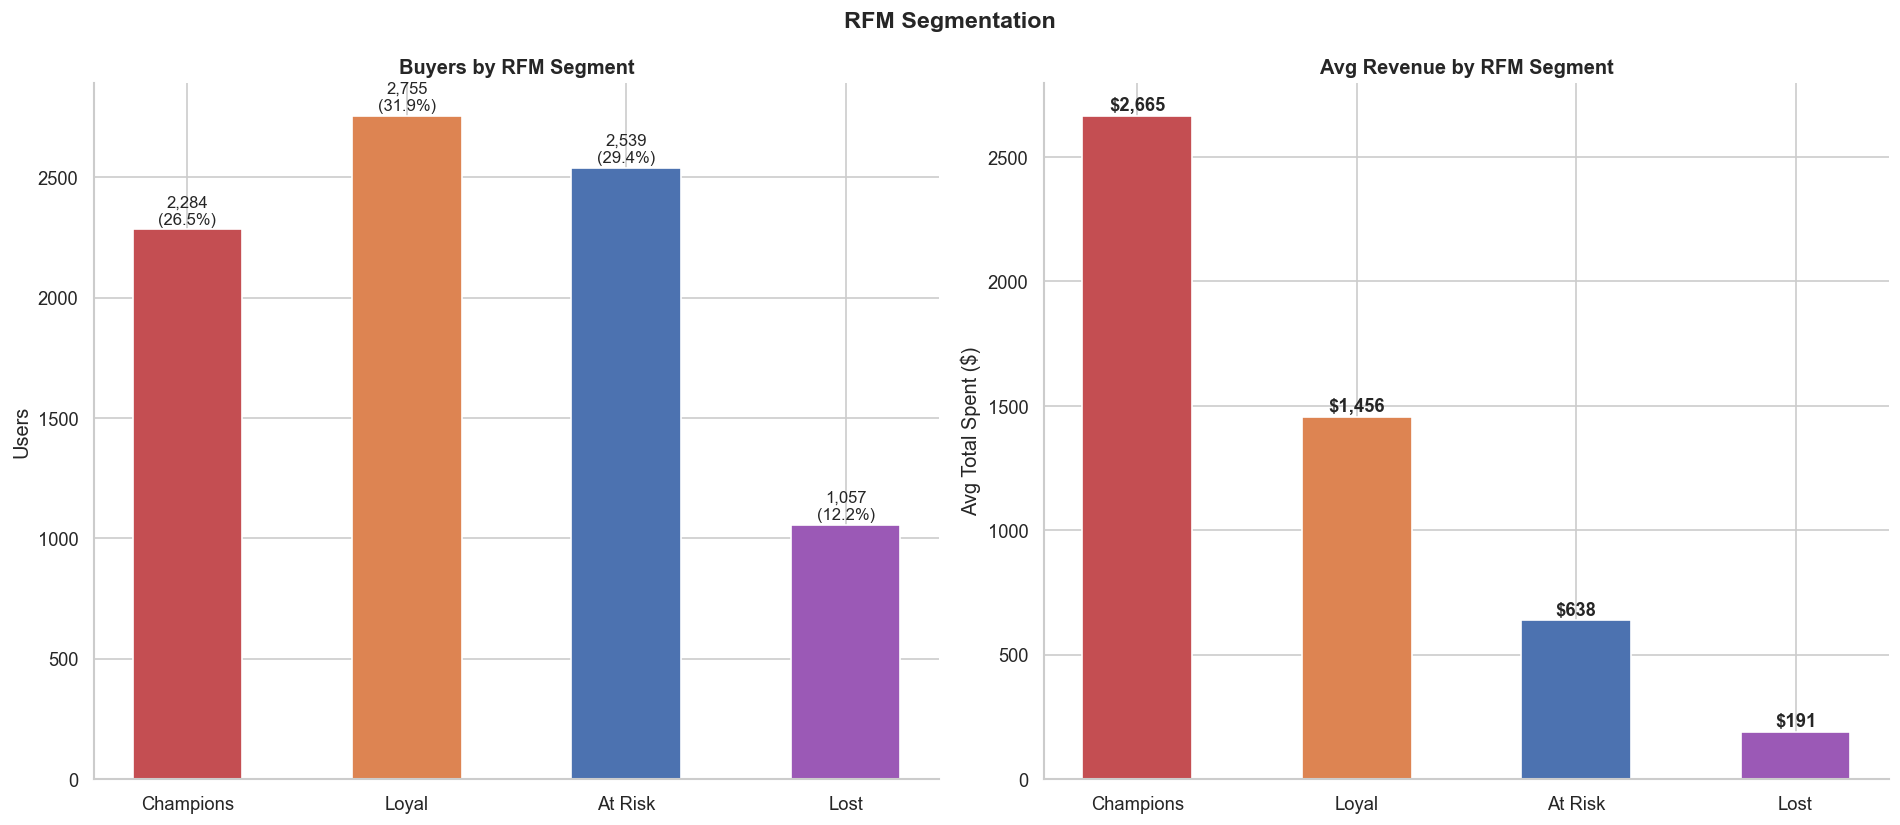

In [18]:
colors_rfm = ['#C44E52', '#DD8452', '#4C72B0', '#9B59B6']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

counts = rfm_summary['count'].values
bars = axes[0].bar(seg_order, counts, color=colors_rfm, width=0.5, edgecolor='white')
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f"{val:,}\n({val/len(buyers)*100:.1f}%)",
                 ha='center', va='bottom', fontsize=10)
axes[0].set_title("Buyers by RFM Segment", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Users")
sns.despine(ax=axes[0])

avg_spends = rfm_summary['avg_spend'].values
bars2 = axes[1].bar(seg_order, avg_spends, color=colors_rfm, width=0.5, edgecolor='white')
for bar, val in zip(bars2, avg_spends):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f"${val:,.0f}", ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title("Avg Revenue by RFM Segment", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Avg Total Spent ($)")
sns.despine(ax=axes[1])

fig.suptitle("RFM Segmentation", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

User value is highly concentrated in the Champions and Loyal segments, which together represent nearly 60% of users but generate disproportionally higher spending and order frequency. In contrast, nearly 40% of users are in declining or inactive states, contributing significantly lower value and showing clear churn progression over time.

---

## Key Findings

Revenue is primarily driven by a relatively small cohort of repeat and high-value users, while the majority of users show limited purchasing depth and short engagement cycles, making retention the dominant growth lever over acquisition.